In [30]:
import pdfplumber
import pandas as pd
import re
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    cohen_kappa_score,
    root_mean_squared_error
)
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
DATA_PATH = "./Data.pdf"
CSV_PATH_GPT4 = "../risultati/AETERNA/risultati_eval_GPT4.1.csv"
# CSV_PATH = "../risultati/nuovi_risultati_eval.csv"
# CSV_PATH_2 = "../risultati/nuovi_risultati_eval.csv"
# CSV_PATH_2 = "../risultati/SemSim_nuovi_risultati_eval.csv"
CSV_PATH_GPT5 = "../risultati/risultati_eval_5-mini.csv"
NEW_EVALUATING = "../risultati_eval_GPT-4.1.csv"
RIPROVA = "./risultati_eval_GPT4.1.csv"
METRICS = [
    "Faithfulness",
    "Answer_Relevancy",
    "Context_Precision",
    "Context_Recall",
    "Noise_Sensitivity",
    "Semantic_Similarity",
    "Answer_Correctness",
]

In [32]:

def extract_values(pdf_path):
    results = []
    with pdfplumber.open(pdf_path) as pdf:
        full_text = "".join([page.extract_text() + "\n" for page in pdf.pages])
    questions = re.split(r"Question \d+:", full_text)

    for i in range(1, len(questions)):
        content = questions[i]
        domanda_text = content.split("Ground Truth:")[0].strip()
        metrics = {
            "ID": i,
            "Question": domanda_text,
            "Faithfulness": get_metric(r"Faithfulness[\s\S]*?(\d\.\d+)", content),
            "Answer_Relevancy": get_metric(
                r"Answer Relevancy[\s\S]*?(\d\.\d+)", content
            ),
            "Context_Precision": get_metric(
                r"Context Precision[\s\S]*?(\d\.\d+)", content
            ),
            "Context_Recall": get_metric(r"Context Recall[\s\S]*?(\d\.\d+)", content),
            "Noise_Sensitivity": get_metric(
                r"Noise Sensitivity[\s\S]*?(\d\.\d+)", content
            ),
            "Semantic_Similarity": get_metric(
                r"Semantic Similarity[\s\S]*?(\d\.\d+)", content
            ),
            "Answer_Correctness": get_metric(
                r"Answer Correctness[\s\S]*?(\d\.\d+)", content
            ),
        }
        results.append(metrics)
    return pd.DataFrame(results)


def get_metric(pattern, block):
    match = re.search(pattern, block, re.IGNORECASE)
    if match:
        val_str = match.group(1).replace(",", ".")
        try:
            return float(val_str)
        except ValueError:
            return np.nan
    return np.nan

In [33]:

def clear_csv(csv_path):
    df = pd.read_csv(csv_path)
    df["ID"] = range(1, len(df) + 1)
    df_final = df[
        [
            "ID",
            "question",
            "faithfulness",
            "answer_relevancy",
            "context_precision",
            "context_recall",
            "noise_sensitivity(mode=relevant)",
            "semantic_similarity",
            "answer_correctness",
        ]
    ]
    return df_final.rename(
        columns={
            "ID": "ID",
            "question": "Question",
            "faithfulness": "Faithfulness",
            "answer_relevancy": "Answer_Relevancy",
            "context_precision": "Context_Precision",
            "context_recall": "Context_Recall",
            "noise_sensitivity(mode=relevant)": "Noise_Sensitivity",
            "semantic_similarity": "Semantic_Similarity",
            "answer_correctness": "Answer_Correctness",
        }
    )

In [34]:
df_manuale = extract_values(DATA_PATH)
# print(df_manuale.head(50))
df_manuale.drop("Question", axis=1, inplace=True)
df_manuale = df_manuale.add_suffix("_man")

In [35]:
print(df_manuale.head())
percorso_output = "./eval_manuale.csv"
df_manuale.to_csv(percorso_output, index=False, encoding="utf-8-sig")

   ID_man  Faithfulness_man  Answer_Relevancy_man  Context_Precision_man  \
0       1               1.0                   1.0                    1.0   
1       2               1.0                   0.6                    0.8   
2       3               0.5                   0.7                    0.0   
3       4               0.0                   0.7                    0.0   
4       5               1.0                   0.7                    1.0   

   Context_Recall_man  Noise_Sensitivity_man  Semantic_Similarity_man  \
0                 1.0                    0.0                      1.0   
1                 0.7                    0.8                      0.6   
2                 0.2                    1.0                      0.1   
3                 0.0                    1.0                      0.0   
4                 1.0                    0.4                      0.6   

   Answer_Correctness_man  
0                     1.0  
1                     0.4  
2                   

In [36]:

# df_2 = clear_csv(CSV_PATH_2)
# df_2.drop("Question", axis=1, inplace=True)
# df_2 = df_2.add_suffix("_model_2")

In [39]:
df_gpt_eval = clear_csv(RIPROVA)
# print(df_gpt_eval.head(50))
df_gpt_eval.drop("Question", axis=1, inplace=True)
df_gpt_eval = df_gpt_eval.add_suffix("_model")

In [40]:
print(df_gpt_eval.head())

   ID_model  Faithfulness_model  Answer_Relevancy_model  \
0         1            1.000000                0.863122   
1         2            0.818182                0.892714   
2         3            0.312500                0.842521   
3         4            0.000000                0.000000   
4         5            0.500000                0.863306   

   Context_Precision_model  Context_Recall_model  Noise_Sensitivity_model  \
0                      1.0              1.000000                 1.000000   
1                      1.0              0.750000                 0.538462   
2                      0.0              0.307692                 0.000000   
3                      1.0              1.000000                 0.071429   
4                      1.0              1.000000                 0.000000   

   Semantic_Similarity_model  Answer_Correctness_model  
0                   0.895952                  0.523988  
1                   0.895326                  0.514154  
2          

In [41]:

df = pd.merge(df_manuale, df_gpt_eval, left_on="ID_man", right_on="ID_model")
# df = pd.merge(df_2, df_gpt_eval, left_on="ID_model_2", right_on="ID_model")

In [42]:
print(df.head())
print(df.info())

   ID_man  Faithfulness_man  Answer_Relevancy_man  Context_Precision_man  \
0       1               1.0                   1.0                    1.0   
1       2               1.0                   0.6                    0.8   
2       3               0.5                   0.7                    0.0   
3       4               0.0                   0.7                    0.0   
4       5               1.0                   0.7                    1.0   

   Context_Recall_man  Noise_Sensitivity_man  Semantic_Similarity_man  \
0                 1.0                    0.0                      1.0   
1                 0.7                    0.8                      0.6   
2                 0.2                    1.0                      0.1   
3                 0.0                    1.0                      0.0   
4                 1.0                    0.4                      0.6   

   Answer_Correctness_man  ID_model  Faithfulness_model  \
0                     1.0         1          

In [43]:
for col in METRICS:
    s1 = df[f"{col}_man"]
    # s1 = df[f"{col}_model_2"]
    s2 = df[f"{col}_model"]
    mask = s1.notna() & s2.notna()
    s1_clean, s2_clean = s1[mask], s2[mask]
    if len(s1_clean) > 2:
        mae = mean_absolute_error(s1_clean, s2_clean)
        spearman = spearmanr(s1_clean, s2_clean).correlation
        rmse = root_mean_squared_error(s1_clean, s2_clean)
        c1 = (s1_clean * 4 + 1).round().astype(int)
        c2 = (s2_clean * 4 + 1).round().astype(int)
        if c1.nunique() > 1 or c2.nunique() > 1 or (c1 != c2).any():
            cohen_weighted = cohen_kappa_score(
                c1, c2, 
                labels=list(set(c1).union(set(c2))), 
                weights='quadratic'
            )
            cohen_str = f"{cohen_weighted:.4f} (Quadratic Weighted)"
        else:
            cohen_str = "Incalcolabile => Varianza Zero"
        print(
            f"{col:<20} | Righe: {len(s1_clean):<2} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | Spearman: {spearman:.4f} | Cohen-Weighted: {cohen_str}"
        )
    else:
        print(
            f"{col}: righe valutate = {len(s1_clean)} => Troppi pochi dati per la valutazione"
        )

Faithfulness         | Righe: 48 | MAE: 0.2310 | RMSE: 0.3260 | Spearman: 0.6714 | Cohen-Weighted: 0.6168 (Quadratic Weighted)
Answer_Relevancy     | Righe: 48 | MAE: 0.3290 | RMSE: 0.4251 | Spearman: -0.0603 | Cohen-Weighted: -0.1512 (Quadratic Weighted)
Context_Precision    | Righe: 48 | MAE: 0.2972 | RMSE: 0.4843 | Spearman: 0.6106 | Cohen-Weighted: 0.4593 (Quadratic Weighted)
Context_Recall       | Righe: 48 | MAE: 0.3480 | RMSE: 0.5315 | Spearman: 0.3674 | Cohen-Weighted: 0.3417 (Quadratic Weighted)
Noise_Sensitivity    | Righe: 45 | MAE: 0.7138 | RMSE: 0.8047 | Spearman: -0.4694 | Cohen-Weighted: -0.2393 (Quadratic Weighted)
Semantic_Similarity  | Righe: 48 | MAE: 0.3883 | RMSE: 0.4870 | Spearman: 0.4709 | Cohen-Weighted: 0.3226 (Quadratic Weighted)
Answer_Correctness   | Righe: 48 | MAE: 0.2467 | RMSE: 0.3053 | Spearman: 0.7323 | Cohen-Weighted: 0.5775 (Quadratic Weighted)


In [ ]:
df_errori = pd.DataFrame()

for col in METRICS:
    df_errori[col] = (df[f"{col}_man"] - df[f"{col}_model"]).abs()

if "question" in df.columns:
    df_errori["question"] = df["question"]

available_metrics = [col for col in METRICS if col in df_errori.columns]

df_melted = df_errori.melt(
    id_vars=["question"] if "question" in df_errori.columns else [],
    value_vars=available_metrics,
    var_name="Metrica Ragas",
    value_name="Discrepanza Assoluta",
)

C:\Users\Gabriele\AppData\Local\Temp\ipykernel_9916\263982384.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


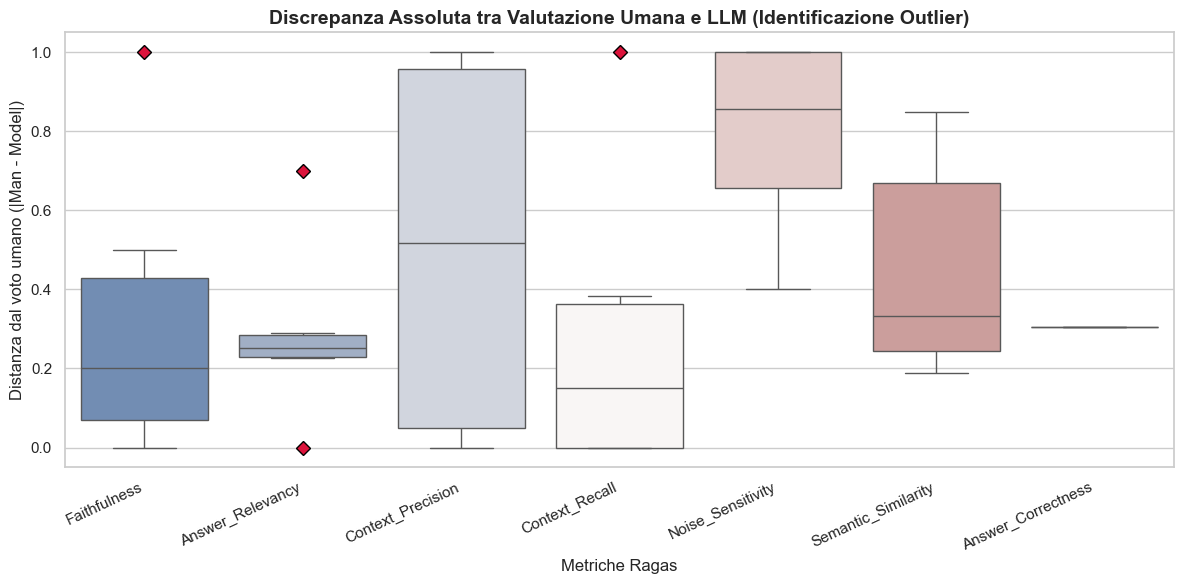

In [ ]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    x="Metrica Ragas",
    y="Discrepanza Assoluta",
    data=df_melted,
    palette="vlag",
    fliersize=7,
    flierprops={
        "marker": "D",
        "markerfacecolor": "crimson",
        "markeredgecolor": "black",
    },
)

plt.xticks(rotation=25, ha="right")
plt.title(
    "Discrepanza Assoluta tra Valutazione Umana e LLM (Identificazione Outlier)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Metriche Ragas", fontsize=12)
plt.ylabel("Distanza dal voto umano (|Man - Model|)", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.tight_layout()

# plt.savefig("risultati/AETERNA/box_plot_discrepanze_real.png", dpi=300)
plt.show()

In [ ]:
RISULTATI_BGE_M3 = "../risultati_BGE_M3.csv"

In [ ]:
df_gpt_eval = clear_csv(RISULTATI_BGE_M3)
# print(df_gpt_eval.head(50))
df_gpt_eval.drop("Question", axis=1, inplace=True)
df_gpt_eval = df_gpt_eval.add_suffix("_model")

FileNotFoundError: [Errno 2] No such file or directory: '../risultati_BGE_M3.csv'

In [ ]:
df = pd.merge(df_manuale, df_gpt_eval, left_on="ID_man", right_on="ID_model")

In [ ]:
for col in METRICS:
    s1 = df[f"{col}_man"]
    # s1 = df[f"{col}_model_2"]
    s2 = df[f"{col}_model"]
    mask = s1.notna() & s2.notna()
    s1_clean, s2_clean = s1[mask], s2[mask]
    if len(s1_clean) > 2:
        mae = mean_absolute_error(s1_clean, s2_clean)
        spearman = spearmanr(s1_clean, s2_clean).correlation
        rmse = root_mean_squared_error(s1_clean, s2_clean)
        c1 = (s1_clean * 4 + 1).round().astype(int)
        c2 = (s2_clean * 4 + 1).round().astype(int)
        if c1.nunique() > 1 or c2.nunique() > 1 or (c1 != c2).any():
            cohen_weighted = cohen_kappa_score(
                c1, c2, 
                labels=list(set(c1).union(set(c2))), 
                weights='quadratic'
            )
            cohen_str = f"{cohen_weighted:.4f} (Quadratic Weighted)"
        else:
            cohen_str = "Incalcolabile => Varianza Zero"
        print(
            f"{col:<20} | Righe: {len(s1_clean):<2} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | Spearman: {spearman:.4f} | Cohen-Weighted: {cohen_str}"
        )
    else:
        print(
            f"{col}: righe valutate = {len(s1_clean)} => Troppi pochi dati per la valutazione"
        )

Faithfulness         | Righe: 20 | MAE: 0.1512 | RMSE: 0.2034 | Spearman: 0.7968 | Cohen-Weighted: 0.8214 (Quadratic Weighted)
Answer_Relevancy     | Righe: 20 | MAE: 0.2533 | RMSE: 0.3010 | Spearman: -0.1158 | Cohen-Weighted: -0.1077 (Quadratic Weighted)
Context_Precision    | Righe: 20 | MAE: 0.2567 | RMSE: 0.4158 | Spearman: 0.7277 | Cohen-Weighted: 0.5639 (Quadratic Weighted)
Context_Recall       | Righe: 20 | MAE: 0.3052 | RMSE: 0.5098 | Spearman: 0.3389 | Cohen-Weighted: 0.3636 (Quadratic Weighted)
Noise_Sensitivity    | Righe: 20 | MAE: 0.7777 | RMSE: 0.8318 | Spearman: -0.6781 | Cohen-Weighted: -0.1667 (Quadratic Weighted)
Semantic_Similarity  | Righe: 20 | MAE: 0.4865 | RMSE: 0.5603 | Spearman: 0.6056 | Cohen-Weighted: 0.2510 (Quadratic Weighted)
Answer_Correctness   | Righe: 20 | MAE: 0.2064 | RMSE: 0.2490 | Spearman: 0.8040 | Cohen-Weighted: 0.5994 (Quadratic Weighted)


In [ ]:
df_errori = pd.DataFrame()

for col in METRICS:
    df_errori[col] = (df[f"{col}_man"] - df[f"{col}_model"]).abs()

if "question" in df.columns:
    df_errori["question"] = df["question"]

available_metrics = [col for col in METRICS if col in df_errori.columns]

df_melted = df_errori.melt(
    id_vars=["question"] if "question" in df_errori.columns else [],
    value_vars=available_metrics,
    var_name="Metrica Ragas",
    value_name="Discrepanza Assoluta",
)

C:\Users\Gabriele\AppData\Local\Temp\ipykernel_19644\263982384.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


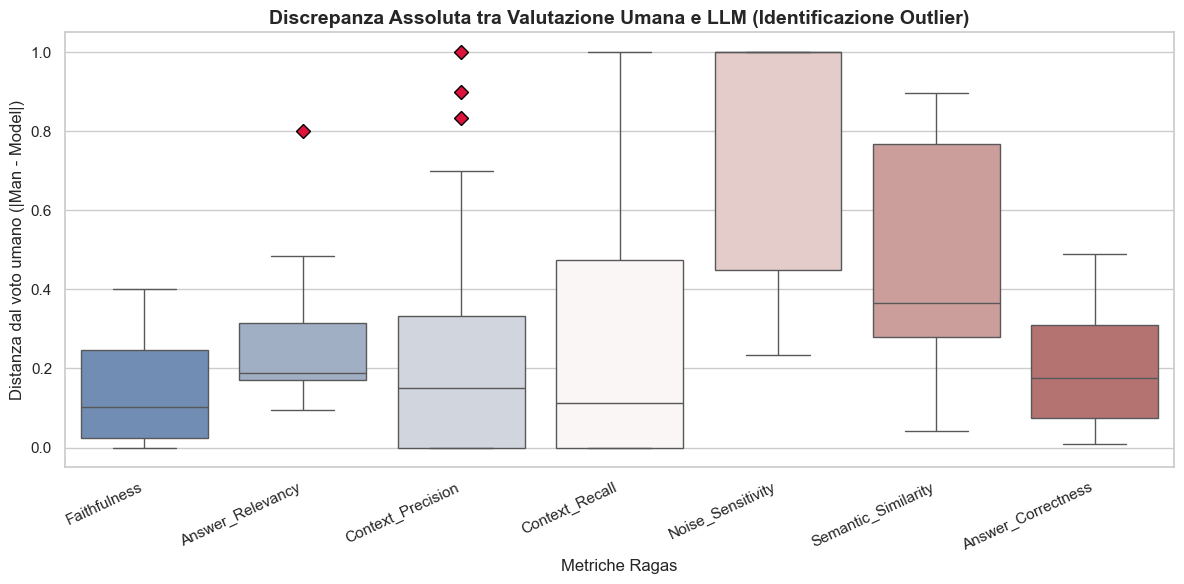

In [ ]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    x="Metrica Ragas",
    y="Discrepanza Assoluta",
    data=df_melted,
    palette="vlag",
    fliersize=7,
    flierprops={
        "marker": "D",
        "markerfacecolor": "crimson",
        "markeredgecolor": "black",
    },
)

plt.xticks(rotation=25, ha="right")
plt.title(
    "Discrepanza Assoluta tra Valutazione Umana e LLM (Identificazione Outlier)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Metriche Ragas", fontsize=12)
plt.ylabel("Distanza dal voto umano (|Man - Model|)", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.tight_layout()

# plt.savefig("risultati/AETERNA/box_plot_discrepanze_real.png", dpi=300)
plt.show()

In [ ]:
df

,ID_man,Faithfulness_man,Answer_Relevancy_man,Context_Precision_man,Context_Recall_man,Noise_Sensitivity_man,Semantic_Similarity_man,Answer_Correctness_man,ID_model,Faithfulness_model,Answer_Relevancy_model,Context_Precision_model,Context_Recall_model,Noise_Sensitivity_model,Semantic_Similarity_model,Answer_Correctness_model
0,1,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1,1.000000,0.901366,1.000000,1.000000,1.000000,0.862352,0.815588
1,2,1.0,0.6,0.8,0.7,0.8,0.6,0.4,2,0.818182,0.928163,1.000000,0.750000,0.454545,0.956766,0.551691
2,3,0.5,0.7,0.0,0.2,1.0,0.1,0.1,3,0.250000,0.885153,0.000000,0.153846,0.125000,0.868946,0.476852
3,4,0.0,0.7,0.0,0.0,1.0,0.0,0.0,4,0.000000,0.954089,1.000000,1.000000,0.000000,0.305368,0.076342
4,5,1.0,0.7,1.0,1.0,0.4,0.6,0.5,5,0.666667,0.896319,1.000000,1.000000,0.000000,0.879806,0.669951
5,6,0.0,0.7,0.0,0.0,1.0,0.0,0.0,6,0.000000,0.886636,0.000000,0.000000,0.000000,0.857453,0.293311
6,7,0.7,0.4,0.8,0.5,0.6,0.1,0.3,7,0.600000,0.884270,1.000000,0.666667,0.200000,0.847047,0.384839
7,8,0.2,0.8,0.0,0.0,1.0,0.0,0.0,8,0.166667,0.894249,0.333333,1.000000,0.000000,0.279022,0.069755
8,9,0.8,0.6,0.4,1.0,0.5,0.4,0.2,9,1.000000,0.988846,0.500000,1.000000,0.000000,0.775779,0.360611
9,10,0.0,0.7,0.0,0.0,1.0,0.0,0.0,10,0.000000,0.869148,0.000000,0.166667,0.000000,0.897173,0.488999


In [ ]:
colonna_domanda = 'ID_man'
record_outlier = []
soglia_errore=0.4

for index, row in df.iterrows():
    domanda_corrente = row[colonna_domanda]
    id_domanda = row['ID_man']
    for col in METRICS:
        voto_umano = row[f"{col}_man"]
        voto_modello = row[f"{col}_model"]
        discrepanza = abs(voto_umano - voto_modello)
        if discrepanza >= soglia_errore:
            record_outlier.append({
                "ID": id_domanda,
                "Metrica": col,
                "Voto mio": round(voto_umano, 2),
                "Voto LLM": round(voto_modello, 2),
                "Discrepanza Assoluta": round(discrepanza, 2)
            })
df_outlier = pd.DataFrame(record_outlier)

In [ ]:
if not df_outlier.empty:
    df_outlier = df_outlier.sort_values(by="Discrepanza Assoluta", ascending=False)

df_outlier

,ID,Metrica,Voto mio,Voto LLM,Discrepanza Assoluta
0,1.0,Noise_Sensitivity,0.0,1.00,1.00
4,4.0,Context_Recall,0.0,1.00,1.00
3,4.0,Context_Precision,0.0,1.00,1.00
7,6.0,Noise_Sensitivity,1.0,0.00,1.00
5,4.0,Noise_Sensitivity,1.0,0.00,1.00
17,11.0,Noise_Sensitivity,1.0,0.00,1.00
14,10.0,Noise_Sensitivity,1.0,0.00,1.00
11,8.0,Context_Recall,0.0,1.00,1.00
12,8.0,Noise_Sensitivity,1.0,0.00,1.00
33,17.0,Noise_Sensitivity,1.0,0.00,1.00


In [ ]:
if not df_outlier.empty:
    df_outlier = df_outlier.sort_values(by="Metrica", ascending=False)

df_outlier

,ID,Metrica,Voto mio,Voto LLM,Discrepanza Assoluta
15,10.0,Semantic_Similarity,0.0,0.90,0.90
28,15.0,Semantic_Similarity,0.0,0.87,0.87
8,6.0,Semantic_Similarity,0.0,0.86,0.86
34,17.0,Semantic_Similarity,0.0,0.78,0.78
2,3.0,Semantic_Similarity,0.1,0.87,0.77
37,19.0,Semantic_Similarity,0.1,0.87,0.77
10,7.0,Semantic_Similarity,0.1,0.85,0.75
25,14.0,Semantic_Similarity,0.2,0.86,0.66
18,11.0,Semantic_Similarity,0.2,0.83,0.63
0,1.0,Noise_Sensitivity,0.0,1.00,1.00
